# A minimal recursive ontology

This notebook makes the recursive part of the Semantic Graphicalizer explicit with a tiny, deterministic example. No language model or network access is needed.

The key design is deliberately small:

```text
Entity = (id, type, relation, attributes)
Relation Entity = Entity with relation != None
Argument edge = Relation Entity --role--> Entity
```

Because a relation is also an `Entity`, an argument may point to another relation. The same schema therefore repeats at every depth: assertions can describe, support, or contain other assertions.

In [1]:
%matplotlib inline

from collections import defaultdict

import matplotlib.pyplot as plt
import networkx as nx
from IPython.display import display

from semantic_graphicalizer import (
    Argument,
    Entity,
    RelationInstance,
    display_graph,
    graph_to_text,
    load_ontology,
    project_binary_relations,
    validate_graph,
)
from semantic_graphicalizer.graph import materialize_graph

## 1. The whole ontology fits on one screen

There are only five entity types and four relations. The important choice is that `Proposition` is a normal entity type, so a proposition can legally fill an argument role whose allowed type is also `Proposition`.

In [2]:
ontology = load_ontology({
    'name': 'minimal-recursive',
    'version': '1.0',
    'terms': [
        {'id': 'Thing', 'description': 'A concrete entity or object.'},
        {'id': 'Person', 'description': 'A person who can hold or communicate a proposition.'},
        {'id': 'Event', 'description': 'An event or state in the world.'},
        {'id': 'Concept', 'description': 'An abstract topic or idea.'},
        {'id': 'Proposition', 'description': 'An entity that reifies an assertion and its arguments.'},
    ],
    'argument_roles': [
        {'id': 'cause', 'description': 'The cause side of a causal assertion.'},
        {'id': 'effect', 'description': 'The effect side of a causal assertion.'},
        {'id': 'believer', 'description': 'The person holding a proposition.'},
        {'id': 'content', 'description': 'The proposition held by a person.'},
        {'id': 'evidence', 'description': 'A proposition used as evidence.'},
        {'id': 'claim', 'description': 'A proposition supported by evidence.'},
        {'id': 'subject', 'description': 'The entity being discussed.'},
        {'id': 'topic', 'description': 'The concept the subject is about.'},
    ],
    'relations': {
        'causes': {
            'description': 'One event or proposition causes another event or proposition.',
            'arguments': {
                'cause': {'cardinality': 1, 'allowed_types': ['Event', 'Proposition']},
                'effect': {'cardinality': 1, 'allowed_types': ['Event', 'Proposition']},
            },
            'projection': ['cause', 'effect'],
            'category': 'causal',
        },
        'believes': {
            'description': 'A person holds a proposition.',
            'arguments': {
                'believer': {'cardinality': 1, 'allowed_types': ['Person']},
                'content': {'cardinality': 1, 'allowed_types': ['Proposition']},
            },
            'projection': ['believer', 'content'],
        },
        'supports': {
            'description': 'One proposition supports another proposition.',
            'arguments': {
                'evidence': {'cardinality': 1, 'allowed_types': ['Proposition']},
                'claim': {'cardinality': 1, 'allowed_types': ['Proposition']},
            },
            'projection': ['evidence', 'claim'],
        },
        'about': {
            'description': 'An entity or proposition is about a concept.',
            'arguments': {
                'subject': {'cardinality': 1, 'allowed_types': ['Thing', 'Person', 'Event', 'Proposition']},
                'topic': {'cardinality': 1, 'allowed_types': ['Concept']},
            },
            'projection': ['subject', 'topic'],
        },
    },
})

print(ontology.as_prompt())

Ontology: minimal-recursive (version 1.0)
Entity types:
- Thing: A concrete entity or object.
- Person: A person who can hold or communicate a proposition.
- Event: An event or state in the world.
- Concept: An abstract topic or idea.
- Proposition: An entity that reifies an assertion and its arguments.
Argument roles:
- cause: The cause side of a causal assertion.
- effect: The effect side of a causal assertion.
- believer: The person holding a proposition.
- content: The proposition held by a person.
- evidence: A proposition used as evidence.
- claim: A proposition supported by evidence.
- subject: The entity being discussed.
- topic: The concept the subject is about.
Relations:
- causes: One event or proposition causes another event or proposition. (cause [1..1; types: Event, Proposition], effect [1..1; types: Event, Proposition]; projection: cause -> effect; category: causal)
- believes: A person holds a proposition. (believer [1..1; types: Person], content [1..1; types: Propositi

## 2. Build five levels of assertion nesting

The graph starts with ordinary entities, then wraps them in propositions:

1. `rain causes wet-ground`
2. `Maya believes [1]`
3. `[1] supports [2]`
4. `[3] is about weather`
5. `Niko believes [4]`

Levels 2–5 are not special cases. They are the same `RelationInstance` shape as level 1; only their argument targets change.

In [3]:
atomic_entities = [
    Entity('maya', 'Person', attributes={'mentions': ['Maya']}),
    Entity('niko', 'Person', attributes={'mentions': ['Niko']}),
    Entity('rain', 'Event', attributes={'mentions': ['rain']}),
    Entity('wet-ground', 'Event', attributes={'mentions': ['wet ground']}),
    Entity('weather', 'Concept', attributes={'mentions': ['weather']}),
]

nested_propositions = [
    RelationInstance(
        'prop::rain-causes-wet-ground', 'Proposition', 'causes',
        (Argument('cause', 'rain'), Argument('effect', 'wet-ground')),
        {'mentions': ['rain causes wet ground'], 'depth': 1},
    ),
    RelationInstance(
        'prop::maya-believes-rain-causes-wet-ground', 'Proposition', 'believes',
        (Argument('believer', 'maya'), Argument('content', 'prop::rain-causes-wet-ground')),
        {'mentions': ['Maya believes that rain causes wet ground'], 'depth': 2},
    ),
    RelationInstance(
        'prop::evidence-supports-belief', 'Proposition', 'supports',
        (
            Argument('evidence', 'prop::rain-causes-wet-ground'),
            Argument('claim', 'prop::maya-believes-rain-causes-wet-ground'),
        ),
        {'mentions': ['the causal proposition supports Maya’s belief'], 'depth': 3},
    ),
    RelationInstance(
        'prop::support-is-about-weather', 'Proposition', 'about',
        (Argument('subject', 'prop::evidence-supports-belief'), Argument('topic', 'weather')),
        {'mentions': ['the support relation is about weather'], 'depth': 4},
    ),
    RelationInstance(
        'prop::niko-believes-support-is-about-weather', 'Proposition', 'believes',
        (Argument('believer', 'niko'), Argument('content', 'prop::support-is-about-weather')),
        {'mentions': ['Niko believes that the support relation is about weather'], 'depth': 5},
    ),
]

graph = materialize_graph(
    atomic_entities,
    nested_propositions,
    ontology,
    document_id='recursive-demo',
    document_text='A five-level explicit recursive ontology example.',
)
validate_graph(graph, ontology)

relation_nodes = [node for node, data in graph.nodes(data=True) if data['relation'] is not None]
recursive_edges = [
    (source, target, data['role'])
    for source, target, data in graph.edges(data=True)
    if graph.nodes[target]['relation'] is not None
]
print(f'{graph.number_of_nodes()} total entities')
print(f'{len(relation_nodes)} relation entities')
print(f'{len(recursive_edges)} argument edges point to another relation entity')
print('Validation: OK')

10 total entities
5 relation entities
5 argument edges point to another relation entity
Validation: OK


In [4]:
def recursive_depth(node_id):
    data = graph.nodes[node_id]
    if data['relation'] is None:
        return 0
    relation_child_depths = [
        recursive_depth(target)
        for _, target in graph.out_edges(node_id)
        if graph.nodes[target]['relation'] is not None
    ]
    return 1 + max(relation_child_depths, default=0)

depth_by_node = {node: recursive_depth(node) for node in graph.nodes}
depth_by_node

{'maya': 0,
 'niko': 0,
 'rain': 0,
 'wet-ground': 0,
 'weather': 0,
 'prop::rain-causes-wet-ground': 1,
 'prop::maya-believes-rain-causes-wet-ground': 2,
 'prop::evidence-supports-belief': 3,
 'prop::support-is-about-weather': 4,
 'prop::niko-believes-support-is-about-weather': 5}

## 3. The canonical reified graph

This view keeps the relation entities visible. Read arrows from right to left: an outer proposition points through named argument roles to inner propositions or atomic entities.

In [11]:
display_graph(
    graph,
    mode='dynamic',
    show_derived_links=True,
    show_source=True,
    max_width=24,
    width=1250,
    height=760,
)

In [6]:
print(graph_to_text(graph, show_derived_links=False))

proposition [causes]: rain causes wet ground
    cause: event: rain
    effect: event: wet ground
proposition [believes]: Maya believes that rain causes wet ground
    believer: person: Maya
    content: proposition: rain causes wet ground
proposition [supports]: the causal proposition supports Maya’s belief
    evidence: proposition: rain causes wet ground
    claim: proposition: Maya believes that rain causes wet ground
proposition [about]: the support relation is about weather
    subject: proposition: the causal proposition supports Maya’s belief
    topic: concept: weather
proposition [believes]: Niko believes that the support relation is about weather
    believer: person: Niko
    content: proposition: the support relation is about weather


## 4. Plot the recursive layers

The left plot places atomic entities at depth 0 and proposition entities at the depth of their deepest proposition argument. The right plot shows how the canonical graph grows as another assertion layer is added.

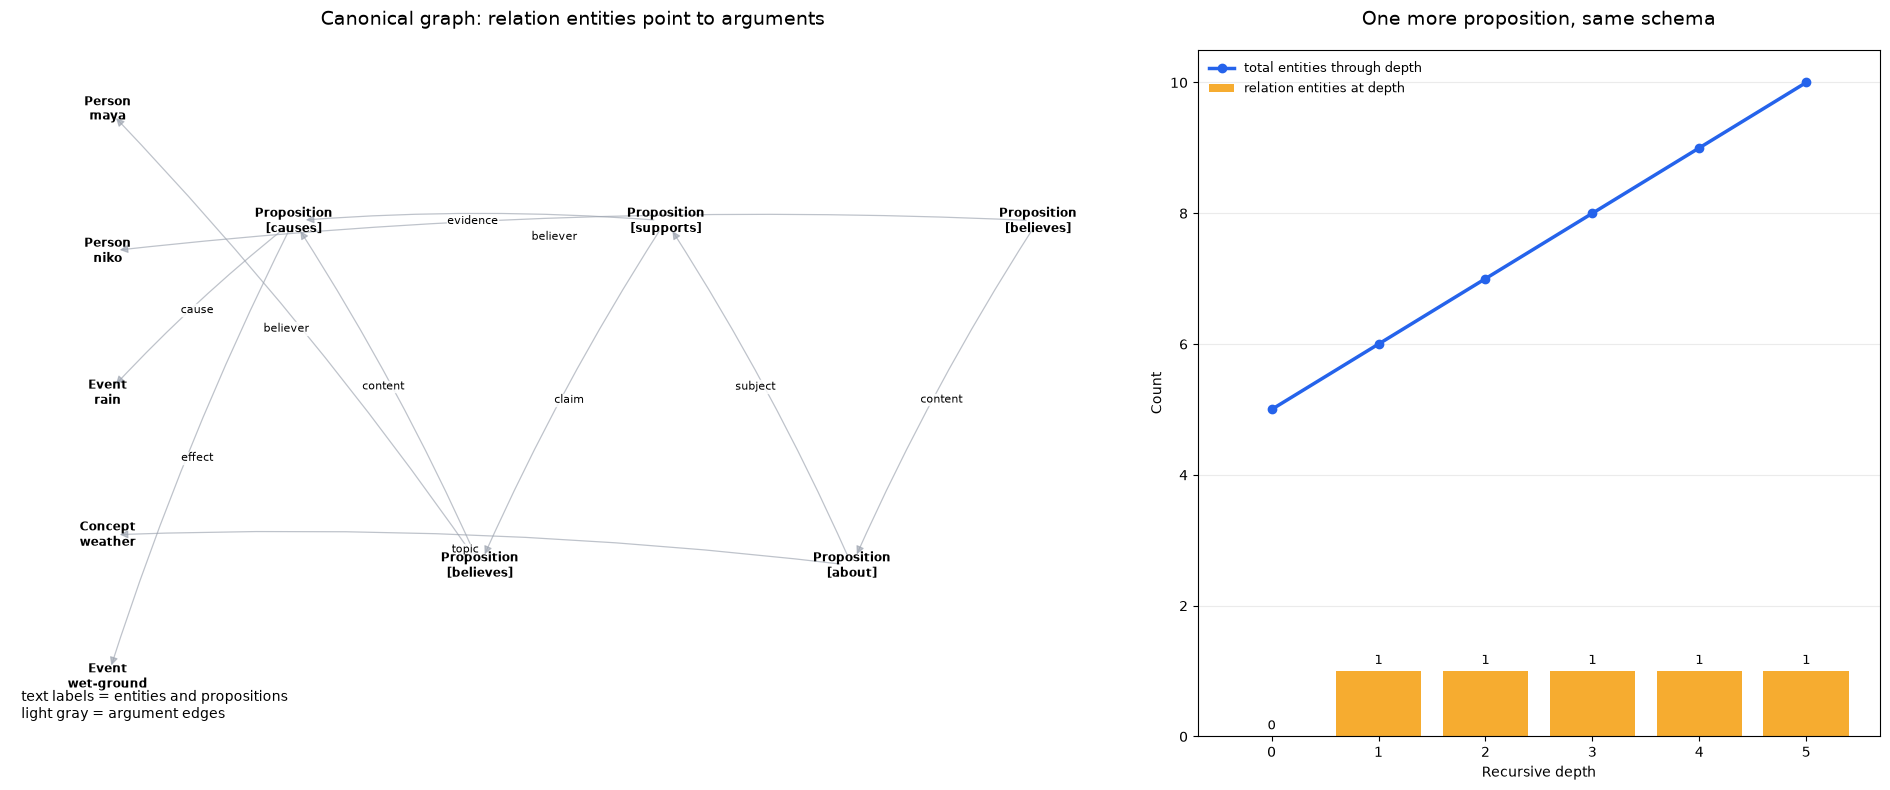

In [14]:
ordered_nodes = sorted(graph.nodes, key=lambda node: (depth_by_node[node], str(node)))
nodes_by_depth = defaultdict(list)
for node in ordered_nodes:
    nodes_by_depth[depth_by_node[node]].append(node)

position = {}
for depth, nodes_at_depth in sorted(nodes_by_depth.items()):
    if depth == 0:
        y_values = [-(index - (len(nodes_at_depth) - 1) / 2) * 0.7 for index in range(len(nodes_at_depth))]
    else:
        zigzag_y = 0.85 if depth % 2 else -0.85
        y_values = [zigzag_y + (index - (len(nodes_at_depth) - 1) / 2) * 0.22 for index in range(len(nodes_at_depth))]
    for node, y_value in zip(nodes_at_depth, y_values):
        position[node] = (depth, y_value)

fig, (graph_axis, growth_axis) = plt.subplots(1, 2, figsize=(19, 8), gridspec_kw={'width_ratios': [1.65, 1]})

nx.draw_networkx_edges(graph, position, ax=graph_axis, arrows=True, arrowstyle='-|>', arrowsize=12, edge_color='#9ca3af', width=0.9, alpha=0.65, connectionstyle='arc3,rad=0.04')
labels = {node: (f"{graph.nodes[node]['type']}\n[{graph.nodes[node]['relation']}]" if graph.nodes[node]['relation'] else f"{graph.nodes[node]['type']}\n{node}") for node in graph.nodes}
nx.draw_networkx_labels(graph, position, labels=labels, ax=graph_axis, font_size=8.5, font_weight='bold', font_color='black')
edge_labels = {(source, target): data['role'] for source, target, data in graph.edges(data=True)}
nx.draw_networkx_edge_labels(graph, position, edge_labels=edge_labels, ax=graph_axis, font_size=8, font_color='black', label_pos=0.52, rotate=False, bbox={'alpha': 0.8, 'color': 'white', 'pad': 0.15})
graph_axis.set_title('Canonical graph: relation entities point to arguments', fontsize=14, pad=18)
graph_axis.set_xlabel('Recursive depth  →', fontsize=11)
graph_axis.set_axis_off()
graph_axis.text(0.01, 0.02, 'text labels = entities and propositions\nlight gray = argument edges', transform=graph_axis.transAxes, fontsize=10, va='bottom')

depths = sorted(nodes_by_depth)
relation_counts = [sum(graph.nodes[node]['relation'] is not None for node in nodes_by_depth[depth]) for depth in depths]
cumulative_nodes = [sum(len(nodes_by_depth[level]) for level in depths if level <= depth) for depth in depths]
bars = growth_axis.bar(depths, relation_counts, color='#f59e0b', alpha=0.85, label='relation entities at depth')
growth_axis.plot(depths, cumulative_nodes, color='#2563eb', marker='o', linewidth=2.5, label='total entities through depth')
growth_axis.bar_label(bars, padding=3, fontsize=9)
growth_axis.set_xticks(depths)
growth_axis.set_xlabel('Recursive depth')
growth_axis.set_ylabel('Count')
growth_axis.set_title('One more proposition, same schema', fontsize=14, pad=18)
growth_axis.grid(axis='y', alpha=0.25)
growth_axis.legend(frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

## 5. Projection does not erase recursion

The optional binary projection makes each ordered two-argument relation readable as a direct edge. Relation entities remain in the node set, so a projected edge can still have a proposition as its source or target.

In [8]:
projected = project_binary_relations(graph, ontology)

for source, target, data in projected.edges(data=True):
    source_kind = 'relation entity' if graph.nodes[source]['relation'] else 'atomic entity'
    target_kind = 'relation entity' if graph.nodes[target]['relation'] else 'atomic entity'
    print(f"{source} ({source_kind}) --{data['predicate']}--> {target} ({target_kind})")

assert any(graph.nodes[source]['relation'] is not None for source, _target in projected.edges())
assert any(graph.nodes[target]['relation'] is not None for _source, target in projected.edges())
print('\nProjection still contains relation entities as endpoints: recursive structure preserved.')

maya (atomic entity) --believes--> prop::rain-causes-wet-ground (relation entity)
niko (atomic entity) --believes--> prop::support-is-about-weather (relation entity)
rain (atomic entity) --causes--> wet-ground (atomic entity)
prop::rain-causes-wet-ground (relation entity) --supports--> prop::maya-believes-rain-causes-wet-ground (relation entity)
prop::evidence-supports-belief (relation entity) --about--> weather (atomic entity)

Projection still contains relation entities as endpoints: recursive structure preserved.


### Takeaway

Recursion is not a separate graph feature layered on top of the ontology. It falls out of one uniform rule: every proposition is an entity, and every proposition exposes its arguments through the same kind of edges.